# House Prices — Exploratory Data Analysis

Kaggle competition: *House Prices: Advanced Regression Techniques*  
Metric: RMSLE (root mean squared log error) — lower is better.

**Sections**
1. Setup & load
2. Target distribution
3. Missing value audit
4. Key numeric relationships & outliers
5. OverallQual breakdown
6. Neighborhood effect
7. Collinearity check

## 1. Setup & load

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

train = pd.read_csv('../data/home-data-for-ml-course/train.csv')
print(f'Shape: {train.shape}')
train.head(3)

Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


## 2. Target distribution

RMSLE penalises predictions on the log scale, so we'll model `log1p(SalePrice)`. This cell confirms the raw target is right-skewed and that the log transform normalises it.

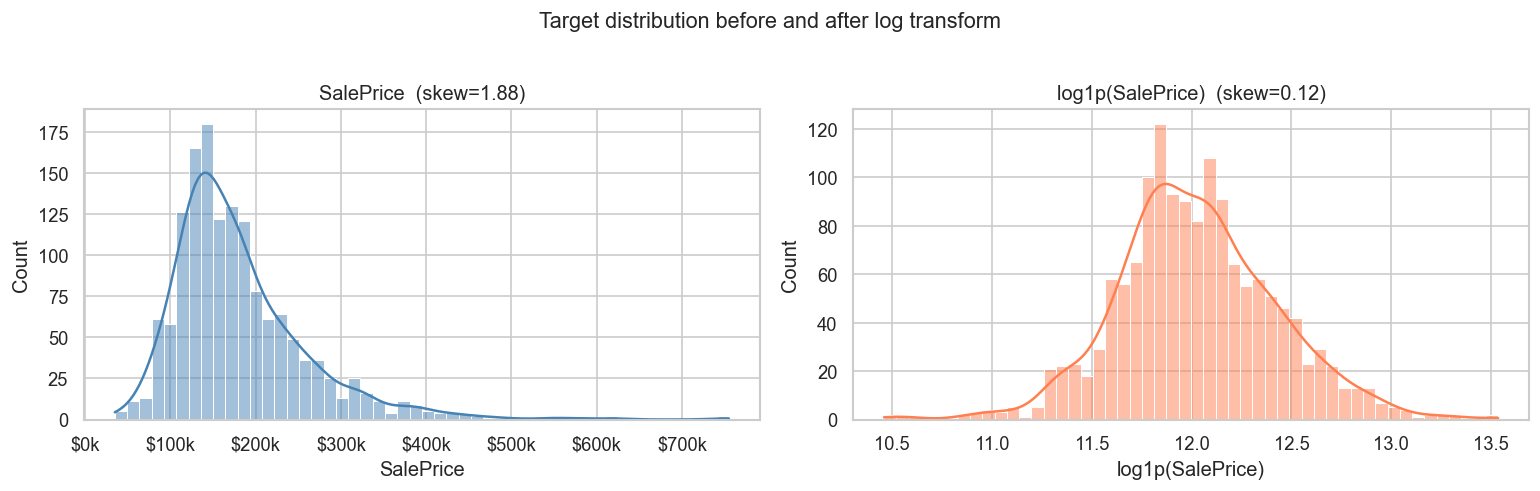

Raw  — mean: $180,921  median: $163,000
Log  — mean: 12.0241  std: 0.3994


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Raw SalePrice
ax = axes[0]
sns.histplot(train['SalePrice'], bins=50, kde=True, ax=ax, color='steelblue')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
skew_raw = train['SalePrice'].skew()
ax.set_title(f'SalePrice  (skew={skew_raw:.2f})')
ax.set_xlabel('SalePrice')

# Log-transformed
log_price = np.log1p(train['SalePrice'])
ax = axes[1]
sns.histplot(log_price, bins=50, kde=True, ax=ax, color='coral')
skew_log = log_price.skew()
ax.set_title(f'log1p(SalePrice)  (skew={skew_log:.2f})')
ax.set_xlabel('log1p(SalePrice)')

plt.suptitle('Target distribution before and after log transform', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

print(f'Raw  — mean: ${train["SalePrice"].mean():,.0f}  median: ${train["SalePrice"].median():,.0f}')
print(f'Log  — mean: {log_price.mean():.4f}  std: {log_price.std():.4f}')

**Observation — target distribution:** `SalePrice` is right-skewed (skewness ≈ 1.88). The log transform is warranted because house prices are multiplicative, not additive — a feature adds a percentage of value, not a fixed dollar amount. The RMSLE metric confirms we should model in log space.

## 3. Missing value audit

Two patterns exist in this dataset:
- **Structural NA** — `NaN` means the feature doesn't exist for that house (e.g. no pool → `PoolQC` is NaN). These should become `"None"` / `0`.
- **True missing** — data simply wasn't recorded. These need imputation (median / mode).

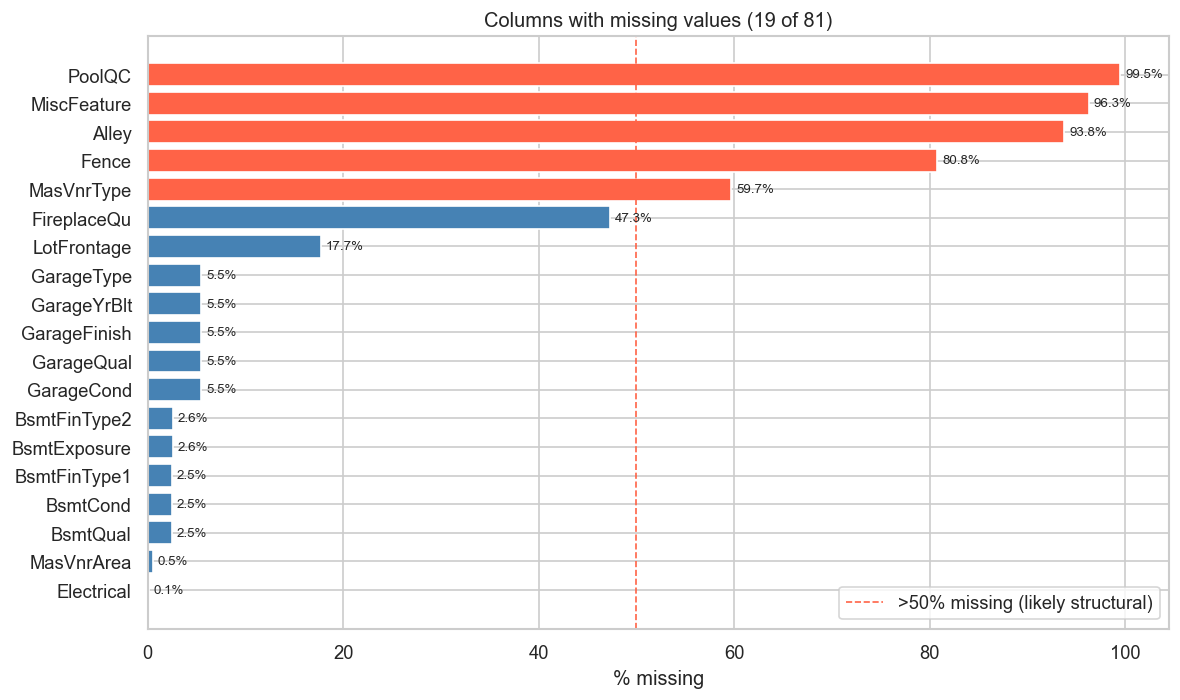


Missing counts:
              count   pct
PoolQC         1453  99.5
MiscFeature    1406  96.3
Alley          1369  93.8
Fence          1179  80.8
MasVnrType      872  59.7
FireplaceQu     690  47.3
LotFrontage     259  17.7
GarageType       81   5.5
GarageYrBlt      81   5.5
GarageFinish     81   5.5
GarageQual       81   5.5
GarageCond       81   5.5
BsmtFinType2     38   2.6
BsmtExposure     38   2.6
BsmtFinType1     37   2.5
BsmtCond         37   2.5
BsmtQual         37   2.5
MasVnrArea        8   0.5
Electrical        1   0.1


In [28]:
missing = (
    train.isnull().sum()
    .pipe(lambda s: s[s > 0])
    .sort_values(ascending=False)
)
missing_pct = (missing / len(train) * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(missing.index[::-1], missing_pct[::-1], color=[
    'tomato' if p > 50 else 'steelblue' for p in missing_pct[::-1]
])
ax.axvline(50, color='tomato', linestyle='--', linewidth=1, label='>50% missing (likely structural)')
ax.set_xlabel('% missing')
ax.set_title(f'Columns with missing values ({len(missing)} of {train.shape[1]})')
ax.legend()
for bar, pct in zip(bars, missing_pct[::-1]):
    ax.text(pct + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()

print('\nMissing counts:')
print(pd.DataFrame({'count': missing, 'pct': missing_pct}).to_string())

In [29]:
# Structural NA columns — NaN means the feature is absent
structural_na = {
    # Categorical → fill 'None'
    'cat': ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
            'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
            'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
            'MasVnrType'],
    # Numeric → fill 0
    'num': ['GarageYrBlt', 'MasVnrArea'],
}

# True missing — needs median / mode imputation
true_missing = ['LotFrontage', 'Electrical']

print('Structural NA (categorical):', structural_na['cat'])
print('Structural NA (numeric):', structural_na['num'])
print('True missing:', true_missing)

Structural NA (categorical): ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType']
Structural NA (numeric): ['GarageYrBlt', 'MasVnrArea']
True missing: ['LotFrontage', 'Electrical']


**Observation — missing values:** Two distinct missing patterns:
- **Structural NAs** (`PoolQC`, `MiscFeature`, `Alley`, `Fence`, `FireplaceQu`): `NaN` means the feature doesn't exist — fill with `"None"`/`0`, not the mean.
- **True missing** (`LotFrontage`, `Electrical`): real data gaps — impute `LotFrontage` with the neighborhood median, `Electrical` with the mode.

## 4. Key numeric relationships & outliers

The five strongest numeric predictors of SalePrice. Scatter plots use the log scale on the y-axis (since we'll model log-price). Red dashed lines mark potential outliers worth reviewing.

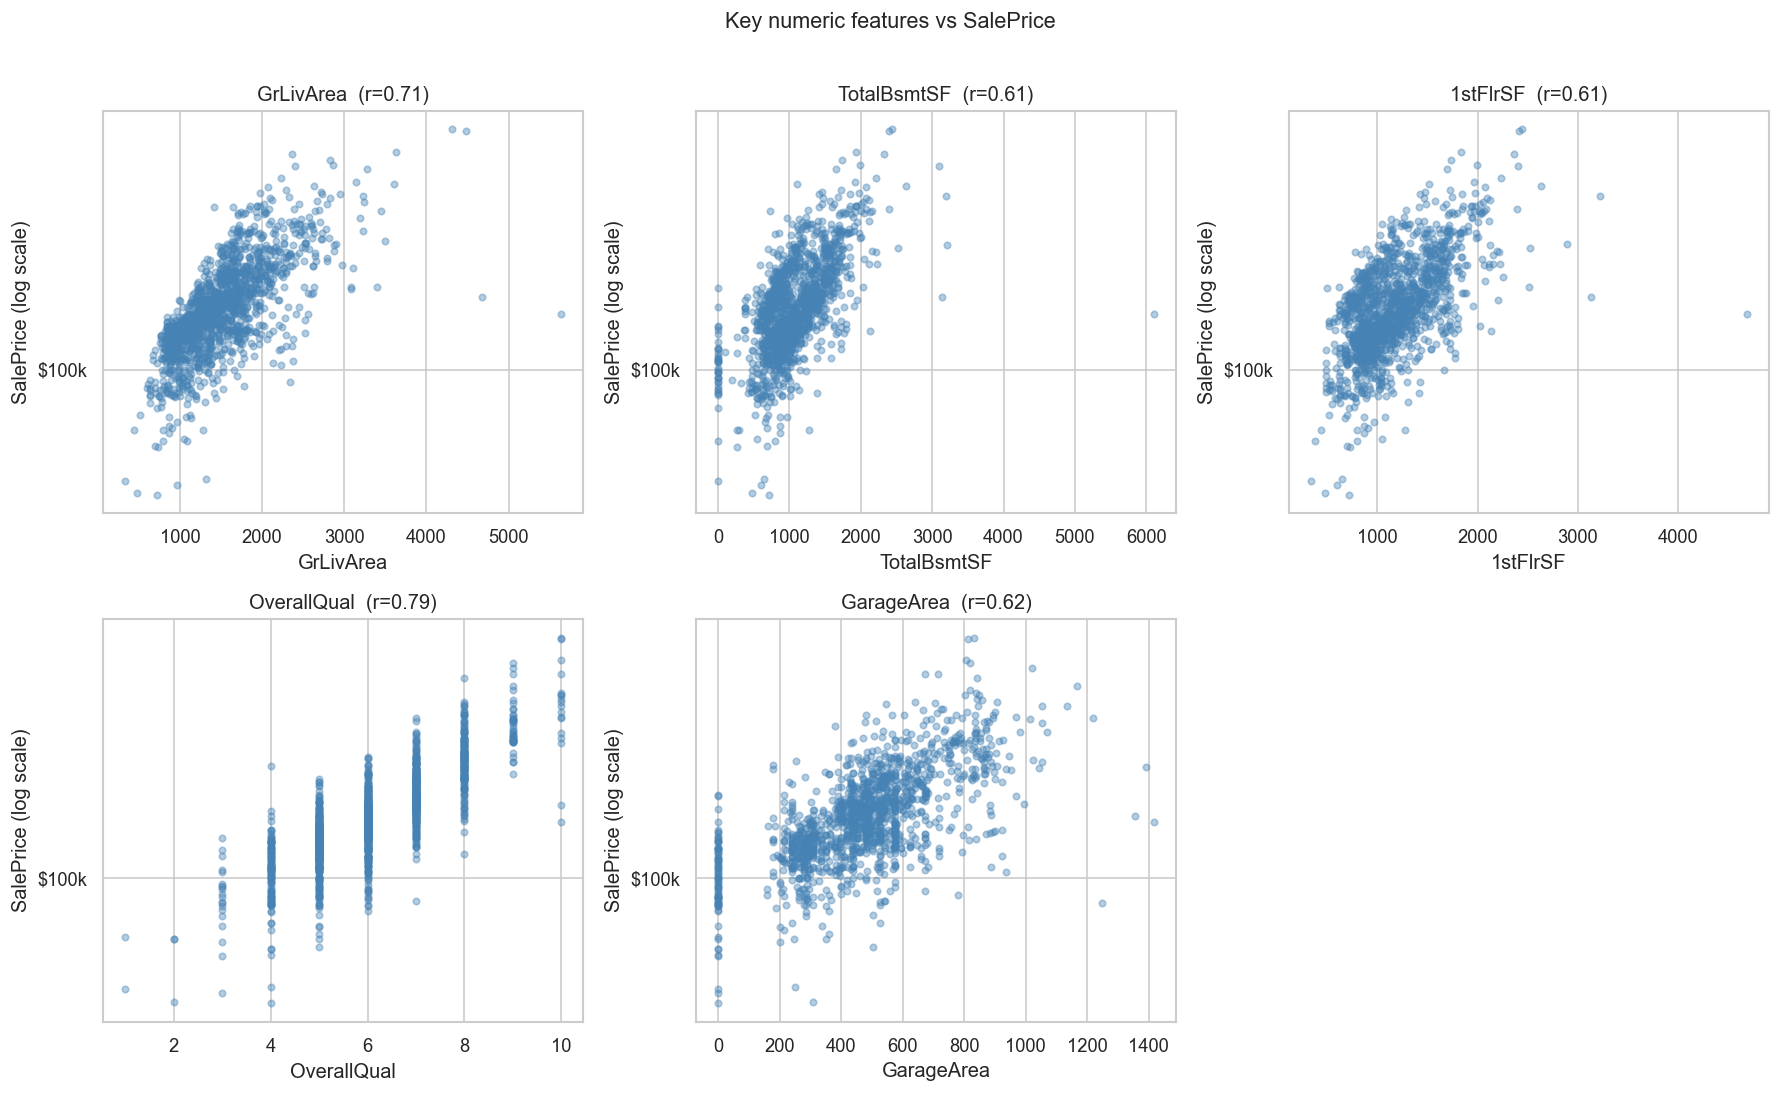

In [30]:
key_features = ['GrLivArea', 'TotalBsmtSF', '1stFlrSF', 'OverallQual', 'GarageArea']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    ax = axes[i]
    ax.scatter(train[feat], train['SalePrice'], alpha=0.4, s=15, color='steelblue')
    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
    corr = train[[feat, 'SalePrice']].corr().iloc[0, 1]
    ax.set_title(f'{feat}  (r={corr:.2f})')
    ax.set_xlabel(feat)
    ax.set_ylabel('SalePrice (log scale)')

# Hide the unused 6th panel
axes[5].set_visible(False)

plt.suptitle('Key numeric features vs SalePrice', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [31]:
# Known outliers in GrLivArea — large houses sold cheap (likely unusual sales)
outliers = train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300_000)]
print(f'Potential GrLivArea outliers: {len(outliers)} rows')
print(outliers[['Id', 'GrLivArea', 'SalePrice', 'OverallQual', 'SaleCondition']].to_string(index=False))

Potential GrLivArea outliers: 2 rows
  Id  GrLivArea  SalePrice  OverallQual SaleCondition
 524       4676     184750           10       Partial
1299       5642     160000           10       Partial


**Observation — numeric relationships:** Plateauing effect visible in `GrLivArea`, `TotalBsmtSF`, `1stFlrSF`, `GarageArea` — consistent with diminishing marginal returns. Consider log-transforming these features. The two outliers (rows 524 and 1299) are massive houses sold cheap as partial sales; keeping for now, to be tested empirically during modelling.

**Observation — garage:** Regime change between no garage and having a garage — a discrete price jump, then a continuous gradient within the garage-having group. **Engineering opportunity:** add a binary `HasGarage` feature to capture the discontinuity and keep `GarageArea` for the within-group gradient. `GarageCars` and `GarageArea` are likely collinear — probably only need one.

## 5. OverallQual breakdown

`OverallQual` is the single strongest predictor (r=0.79). This box plot shows both the median price gradient and the spread within each quality bucket.

/var/folders/7c/rj5y_tcx0_98qk39x1820ftc0000gn/T/ipykernel_31696/1550480586.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='OverallQual', y='SalePrice', order=order, ax=ax,


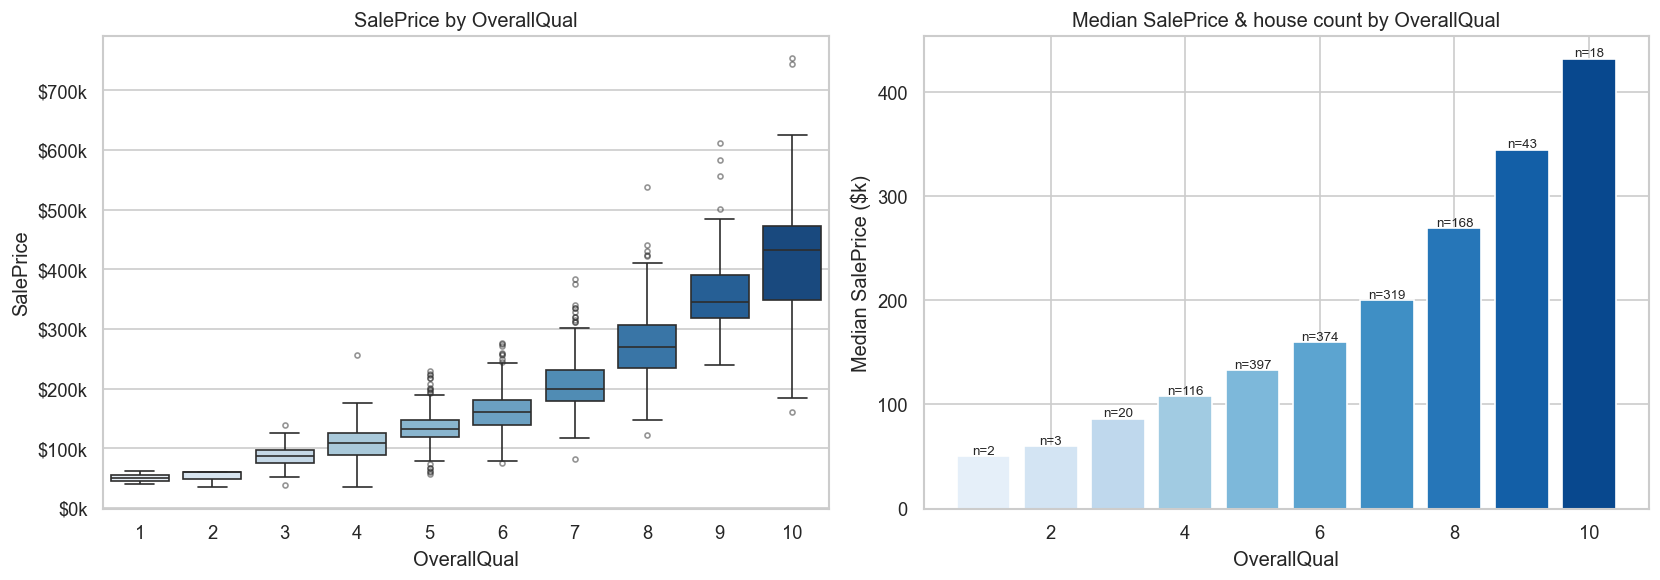

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot on raw scale
ax = axes[0]
order = sorted(train['OverallQual'].unique())
sns.boxplot(data=train, x='OverallQual', y='SalePrice', order=order, ax=ax,
            palette='Blues', flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.5})
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
ax.set_title('SalePrice by OverallQual')

# Median price and count per quality
ax = axes[1]
summary = train.groupby('OverallQual')['SalePrice'].agg(['median', 'count']).reset_index()
bars = ax.bar(summary['OverallQual'], summary['median'] / 1e3, color=sns.color_palette('Blues', len(summary)))
ax.set_xlabel('OverallQual')
ax.set_ylabel('Median SalePrice ($k)')
ax.set_title('Median SalePrice & house count by OverallQual')
for bar, (_, row) in zip(bars, summary.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'n={int(row["count"])}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

**Observation — OverallQual:** Clean positive linear relationship — strongest predictor at r = 0.79. A price floor is visible at quality ≤ 4 — land value creates a minimum regardless of build quality. Possible heteroscedasticity at the high-quality end, but the log transform should address this.

## 6. Neighborhood effect

25 neighborhoods in Ames, Iowa. Sorted by median SalePrice to show the price range across locations — this will be a high-signal categorical feature.

/var/folders/7c/rj5y_tcx0_98qk39x1820ftc0000gn/T/ipykernel_31696/3136136818.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


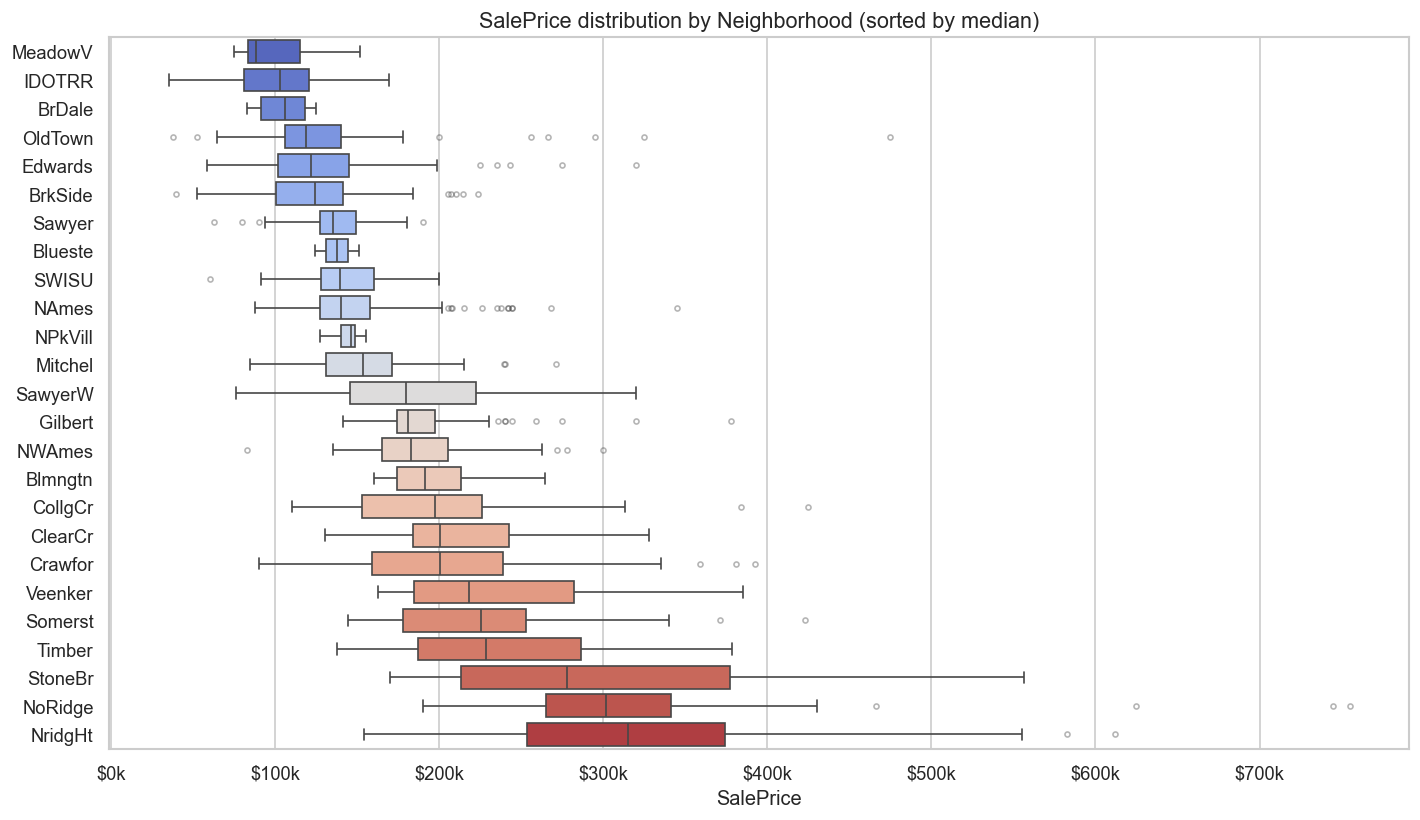

              count    median      mean       std
Neighborhood                                     
NridgHt          77  $315,000  $316,271   $96,393
NoRidge          41  $301,500  $335,295  $121,413
StoneBr          25  $278,000  $310,499  $112,970
Timber           38  $228,475  $242,247   $64,846
Somerst          86  $225,500  $225,380   $56,178
Veenker          11  $218,000  $238,773   $72,369
Crawfor          51  $200,624  $210,625   $68,866
ClearCr          28  $200,250  $212,565   $50,232
CollgCr         150  $197,200  $197,966   $51,404
Blmngtn          17  $191,000  $194,871   $30,393
NWAmes           73  $182,900  $189,050   $37,172
Gilbert          79  $181,000  $192,855   $35,987
SawyerW          59  $179,900  $186,556   $55,652
Mitchel          49  $153,500  $156,270   $36,487
NPkVill           9  $146,000  $142,694    $9,377
NAmes           225  $140,000  $145,847   $33,075
SWISU            25  $139,500  $142,591   $32,623
Blueste           2  $137,500  $137,500   $19,092


In [33]:
neighborhood_order = (
    train.groupby('Neighborhood')['SalePrice']
    .median()
    .sort_values()
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.boxplot(
    data=train,
    x='SalePrice', y='Neighborhood',
    order=neighborhood_order,
    palette='coolwarm',
    flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4},
    ax=ax
)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
ax.set_title('SalePrice distribution by Neighborhood (sorted by median)', fontsize=13)
ax.set_xlabel('SalePrice')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

# Summary table
nbhd_summary = (
    train.groupby('Neighborhood')['SalePrice']
    .agg(count='count', median='median', mean='mean', std='std')
    .sort_values('median', ascending=False)
)
nbhd_summary['median'] = nbhd_summary['median'].map('${:,.0f}'.format)
nbhd_summary['mean'] = nbhd_summary['mean'].map('${:,.0f}'.format)
nbhd_summary['std'] = nbhd_summary['std'].map('${:,.0f}'.format)
print(nbhd_summary.to_string())

## 7. Collinearity check

Heatmap of the top numeric features (by absolute correlation with SalePrice). Highly correlated feature pairs (|r| > 0.8) may need to be deduplicated before fitting linear models.

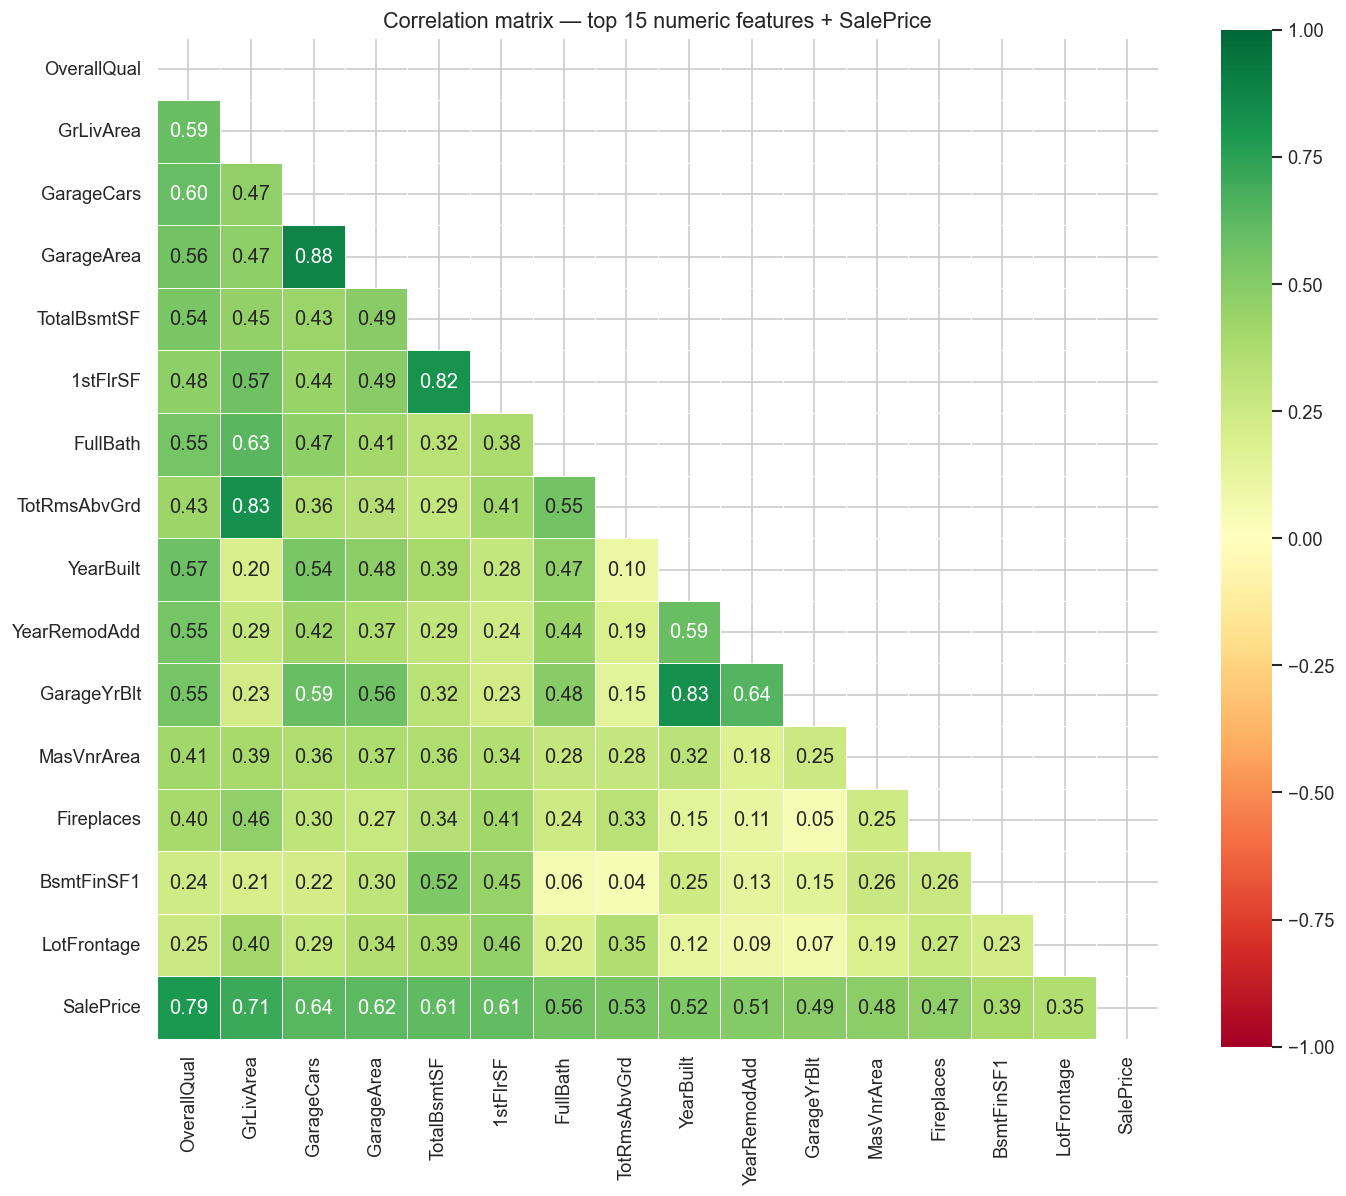

In [34]:
num_cols = train.select_dtypes(include='number').columns.tolist()
corr_with_target = (
    train[num_cols].corr()['SalePrice']
    .drop('SalePrice')
    .abs()
    .sort_values(ascending=False)
)
top_features = corr_with_target.head(15).index.tolist() + ['SalePrice']

corr_matrix = train[top_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Correlation matrix — top 15 numeric features + SalePrice', fontsize=13)
plt.tight_layout()
plt.show()

In [35]:
# Flag highly collinear pairs (|r| > 0.8, excluding self and SalePrice)
features_only = [f for f in top_features if f != 'SalePrice']
corr_feat = train[features_only].corr().abs()

high_corr = [
    (corr_feat.columns[i], corr_feat.columns[j], corr_feat.iloc[i, j])
    for i in range(len(features_only))
    for j in range(i + 1, len(features_only))
    if corr_feat.iloc[i, j] > 0.8
]

print('Highly collinear feature pairs (|r| > 0.80):')
for a, b, r in sorted(high_corr, key=lambda x: -x[2]):
    print(f'  {a:20s} ↔  {b:20s}  r={r:.2f}')

Highly collinear feature pairs (|r| > 0.80):
  GarageCars           ↔  GarageArea            r=0.88
  YearBuilt            ↔  GarageYrBlt           r=0.83
  GrLivArea            ↔  TotRmsAbvGrd          r=0.83
  TotalBsmtSF          ↔  1stFlrSF              r=0.82


## EDA Summary & Modeling Decisions

### Target
- `SalePrice` is right-skewed (skewness ≈ 1.88) — log transform before training. Prices are multiplicative not additive, consistent with RMSLE metric.

### Missing Values
- Structural NAs (`PoolQC`, `MiscFeature`, `Alley`, `Fence`, `FireplaceQu`) mean feature is absent — fill categorical with `"None"`, numeric with `0`.
- True missing: impute `LotFrontage` with neighborhood median, `Electrical` with mode.

### Feature Engineering
- Log transform area features (`GrLivArea`, `TotalBsmtSF`, `GarageArea`) to capture diminishing marginal returns and plateauing effect observed in scatter plots.
- Add `HasGarage` binary (`1` if `GarageArea > 0`) to capture regime change between no garage and having one.
- Add `HasBasement` binary (`1` if `TotalBsmtSF > 0`) for same reason.
- Keep both `TotalBsmtSF` and `1stFlrSF` — they serve different purposes for houses with and without basements. Test `TotalFootprintSF = max(TotalBsmtSF, 1stFlrSF)` as alternative during modeling.
- Target encode `Neighborhood` — preserves full price gradient without high cardinality problem. The tier breakdown below is for human reference and sanity checking only, not used in the model.
- Two known outliers rows 524 and 1299 — partial sales, extremely large houses sold cheap. Keeping for now, test empirically during modeling.

### Collinearity — features to drop
- `GarageYrBlt` (redundant with `YearBuilt`)
- `TotRmsAbvGrd` (redundant with `GrLivArea`)
- Keep both `GarageCars` and `GarageArea` for now — let Lasso decide
- Keep both `TotalBsmtSF` and `1stFlrSF` for now — serve different purposes

### Neighborhood Reference (human sanity check only — model uses target encoding)
- **Tier 1 Luxury:** NridgHt, NoRidge, StoneBr — high median, wide spread, upward outliers
- **Tier 2 Upper Middle:** Timber, Veenker, Somerst
- **Tier 3 Middle:** CollgCr, Crawfor, ClearCr, Blmngtn
- **Tier 4 Lower Middle:** NAmes, Gilbert, NWAmes, SawyerW — tight distributions, occasional upward outliers
- **Tier 5 Affordable:** BrkSide, Edwards, OldTown, Sawyer — lower prices, occasional downward outliers

## Summary & next steps

| Finding | Action |
|---|---|
| `SalePrice` is right-skewed (skew ≈ 1.88) | Model `log1p(SalePrice)`, invert with `expm1` at prediction time |
| 5 columns >80% missing (structural) | Fill with `"None"` / `0` — not dropped |
| `LotFrontage` (18% missing) | Impute per neighborhood median |
| 2 GrLivArea outliers (large house, low price) | Drop before training linear models; keep for tree models |
| `GarageCars`/`GarageArea` collinear (r≈0.88) | Keep one; `GarageCars` has slightly higher target correlation |
| `TotalBsmtSF`/`1stFlrSF` collinear (r≈0.82) | Keep `TotalBsmtSF` — more informative |
| `Neighborhood` spans ~3× price range | Encode as target-encoded or ordinal by median price |

**Recommended next step:** build a preprocessing pipeline + Ridge/Lasso baseline, then layer in XGBoost.

In [36]:
test = pd.read_csv('/Users/austinpemble/Projects/house-prices/data/home-data-for-ml-course/test.csv')
print(test['SaleCondition'].value_counts())

SaleCondition
Normal     1204
Partial     120
Abnorml      89
Family       26
Alloca       12
AdjLand       8
Name: count, dtype: int64


In [37]:
train = pd.read_csv('/Users/austinpemble/Projects/house-prices/data/home-data-for-ml-course/train.csv')
print(train['SaleCondition'].value_counts())

SaleCondition
Normal     1198
Partial     125
Abnorml     101
Family       20
Alloca       12
AdjLand       4
Name: count, dtype: int64


In [44]:
!cd /Users/austinpemble/Projects/house-prices && python3 src/train.py

Loading data...
  Train: (1460, 80)  Test: (1459, 80)

Ridge — 5-fold CV...
  RMSLE: 0.1428 ± 0.0341

Lasso — 5-fold CV...
  RMSLE: 0.1404 ± 0.0355

--- Summary ---
  Ridge  CV RMSLE: 0.1428 ± 0.0341
  Lasso  CV RMSLE: 0.1404 ± 0.0355

Best: lasso (RMSLE 0.1404)
Fitting lasso on full training set...
Submission saved → /Users/austinpemble/Projects/house-prices/submissions/2026-06-01_lasso_0.1404.csv


In [48]:
!cd /Users/austinpemble/Projects/house-prices && python3 src/train.py

Loading data...
  Train: (1460, 80)  Test: (1459, 80)

Ridge — 5-fold CV...
  RMSLE: 0.1428 ± 0.0341

Lasso — 5-fold CV...
  RMSLE: 0.1404 ± 0.0355

XGBoost — 5-fold CV (max_estimators=1000, early_stopping=50)...
  Fold 1: RMSLE=0.1340  best_n_estimators=206
  Fold 2: RMSLE=0.1125  best_n_estimators=347
  Fold 3: RMSLE=0.1485  best_n_estimators=301
  Fold 4: RMSLE=0.1235  best_n_estimators=579
  Fold 5: RMSLE=0.1101  best_n_estimators=672
  RMSLE: 0.1257 ± 0.0142  (avg best_n_estimators=421)

--- CV Summary (RMSLE — lower is better, matches Kaggle leaderboard) ---
  Ridge   0.1428 ± 0.0341
  Lasso   0.1404 ± 0.0355
  XGBoost 0.1257 ± 0.0142  (best_n=421)

XGBoost beats Lasso (0.1257 < 0.1404)
Fitting xgboost on full training set...
Submission saved → /Users/austinpemble/Projects/house-prices/submissions/2026-06-01_xgboost_0.1257.csv


In [46]:
import sys
!{sys.executable} -m pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 13.1 MB/s eta 0:00:00

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


## Where I left off
- EDA fully complete, all observations documented above
- Next step: Phase 2 — build preprocessing pipeline in `src/preprocessing.py`
- Key decisions all summarized in EDA Summary cell above
- During modeling: test `TotalFootprintSF` vs keeping `TotalBsmtSF` and `1stFlrSF` separately
- During modeling: test dropping outlier rows 524 and 1299 vs keeping them